# Cartogram Type Benchmark

This notebook compares the four cartogram types on the same input data with post-processing disabled: Dorling, Demers, Non-Contiguous, and Contiguous.

The goal is to check whether each mode can be created reliably, inspect the raw shapes before cleanup, and measure the solver output with a few simple metrics.

In [1]:
import os
import sys

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_dir not in sys.path:
    sys.path.append(project_dir)

from src.io import loader
from src.geometry import *
from src.geometry.disjoint_pairs import *
from src.core.CartogramFramework import *
from src.core.CartogramFramework_1 import CartogramFramework_1 as CartogramFramework_global

In [2]:
region = 'contiguous/world'
level = 'original_world'
year = 2016

polygons, target_areas, target_positions, names, centroid = loader(region, level, year=year)
horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical_center(polygons)
neighbors = neighbouring_pairs(polygons)
shared_verts = shared_vertices_of_neighbors(polygons)
fixed_points = [np.mean(poly, axis=0) for poly in polygons]

print(f'Region: {region} / {level} / {year}')
print(f'Number of polygons: {len(polygons)}')
print(f'Horizontal pairs: {len(horizontal_pairs)}')
print(f'Vertical pairs: {len(vertical_pairs)}')
print(f'Neighbouring pairs: {len(neighbors)}')
print(f'Shared-vertex groups: {len(shared_verts)}')
print(f'Total target area: {float(np.sum(target_areas)):.6g}')

Matched name column: 'ISO_CODE', value column: 'Population (people)'
Number of unmatched regions for year 2016: 0
Region: contiguous/world / original_world / 2016
Number of polygons: 198
Horizontal pairs: 14658
Vertical pairs: 4845
Neighbouring pairs: 299
Shared-vertex groups: 299
Total target area: 7.78292e+09


In [4]:
def area_error_summary(actual_areas, target_areas):
    actual = np.asarray(actual_areas, dtype=float)
    target = np.asarray(target_areas, dtype=float)
    denom = np.maximum(target, 1e-12)
    rel_err = np.abs(actual - target) / denom
    return {
        'mean_abs_area_err_pct': float(np.nanmean(rel_err) * 100.0),
        'median_abs_area_err_pct': float(np.nanmedian(rel_err) * 100.0),
        'max_abs_area_err_pct': float(np.nanmax(rel_err) * 100.0),
    }


def centroid_shift_summary(polygons, target_centers):
    centroids = np.array([np.mean(np.asarray(poly), axis=0) for poly in polygons], dtype=float)
    targets = np.asarray(target_centers, dtype=float)
    shifts = np.linalg.norm(centroids - targets, axis=1)
    return {
        'mean_centroid_shift': float(np.nanmean(shifts)),
        'median_centroid_shift': float(np.nanmedian(shifts)),
        'max_centroid_shift': float(np.nanmax(shifts)),
    }


def build_metric_row(name, result, target_areas, target_centers):
    polygons_out, actual_areas, status, objective, leaders, target_areas_used = result
    row = {
        'cartogram_type': name,
        'status': status,
        'objective': None if objective is None else float(objective),
        'leaders': len(leaders) if leaders is not None else 0,
        'regions': len(polygons_out),
        'mean_vertices': float(np.mean([len(np.asarray(poly)) for poly in polygons_out])),
    }
    row.update(area_error_summary(actual_areas, target_areas_used))
    row.update(centroid_shift_summary(polygons_out, target_centers))
    row['solver_ok'] = status in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE, 'optimal', 'optimal_inaccurate')
    return row


def draw_panel(ax, polygons, title, target_centers=None, show_centers=True):
    for poly in polygons:
        points = np.asarray(poly, dtype=float)
        closed = np.vstack([points, points[0]])
        ax.fill(closed[:, 0], closed[:, 1], alpha=0.35, linewidth=0.7)
        ax.plot(closed[:, 0], closed[:, 1], linewidth=0.6)
    if show_centers and target_centers is not None:
        centers = np.asarray(target_centers, dtype=float)
        ax.scatter(centers[:, 0], centers[:, 1], s=6, c='black', alpha=0.5, marker='x')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')


def benchmark_cartogram(mode_name, **overrides):
    base_kwargs = dict(
        polygons=polygons,
        target_areas=target_areas,
        fixed_points=None,
        target_centers=target_positions,
        horizontal_pairs=horizontal_pairs,
        vertical_pairs=vertical_pairs,
        neighboring_pairs=neighbors,
        shared_vertices_of_neighbors=shared_verts,
        compute_leaders_flag=False,
        postprocess_contiguous=False,
        postprocess_resolve_overlaps=False,
        postprocess_snap_method='mean',
    )
    base_kwargs.update(overrides)
    print(f'Running {mode_name} ...')
    result = CartogramFramework_global(**base_kwargs)
    row = build_metric_row(mode_name, result, target_areas, target_positions)
    return result, row


benchmarks = [
    (
        'Demers',
        dict(
            shape='square',
            gamma=0.0,
            lambda_shape=0.1,
            lambda_area=1.0,
            lambda_center=0.0,
            lambda_topology=1.0,
            soft_mean_scale=False,
            t_min=0.01,
            t_max=5.0,
        ),
    ),
    (
        'Non-Contiguous',
        dict(
            shape='original',
            gamma=1.0,
            lambda_shape=1.0,
            lambda_area=1.0,
            lambda_center=0.05,
            lambda_topology=0.0,
            soft_mean_scale=True,
            lambda_mean_scale=1e5,
            t_min=0.001,
            t_max=5.0,
        ),
    ),
    (
        'Contiguous (hard)',
        dict(
            shape='contiguous',
            gamma=1.0,
            lambda_shape=1.0,
            lambda_area=1.0,
            lambda_center=0.05,
            lambda_topology=0.0,
            soft_mean_scale=True,
            lambda_mean_scale=1e5,
            contiguous_use_topology=False,
            lambda_repulsion=0.05,
            lambda_vertex_distance=0.15,
            vertex_distance_margin=1.25,
            t_min=0.001,
            t_max=5.0,
        ),
    ),
    (
        'Contiguous (soft)',
        dict(
            shape='contiguous2',
            gamma=1.0,
            lambda_shape=1.0,
            lambda_area=1.0,
            lambda_center=0.05,
            lambda_topology=0.0,
            soft_mean_scale=True,
            lambda_mean_scale=1e5,
            contiguous_use_topology=False,
            lambda_contiguous=3.0,
            lambda_repulsion=0.05,
            lambda_vertex_distance=0.15,
            vertex_distance_margin=1.25,
            t_min=0.001,
            t_max=5.0,
        ),
    ),
]

results = {}
rows = []

for mode_name, kwargs in benchmarks:
    result, row = benchmark_cartogram(mode_name, **kwargs)
    results[mode_name] = result
    rows.append(row)

summary = pd.DataFrame(rows)
summary

Running Demers ...
Contiguous mode 'square': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 1463.92
Running Non-Contiguous ...
Contiguous mode 'original': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 3.39502e+08
Running Contiguous (hard) ...
Contiguous mode 'contiguous': 7055 shared-vertex constraints added.


/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/src/core/CartogramFramework_1.py:720: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob = cp.Problem(objective, constraints)
/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/src/core/CartogramFramework_1.py:721: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob.solve(solver=cp.CLARABEL, verbose=False)


Status : optimal
Obj val: 3.42044e+08
Running Contiguous (soft) ...
Contiguous mode 'contiguous2': 9322 shared-vertex penalty terms added.
Status : optimal
Obj val: 3.39576e+08


,cartogram_type,status,objective,leaders,regions,mean_vertices,mean_abs_area_err_pct,median_abs_area_err_pct,max_abs_area_err_pct,mean_centroid_shift,median_centroid_shift,max_centroid_shift,solver_ok
0,Demers,optimal,1.463921e+03,0,198,64.000000,1.242882e-09,2.213910e-11,5.387240e-08,22.855629,16.688881,76.276693,True
1,Non-Contiguous,optimal,3.395022e+08,0,198,165.893939,4.069819e+00,9.692780e-02,9.921281e+01,14.014448,9.913998,72.689449,True
2,Contiguous (hard),optimal,3.420437e+08,0,198,165.893939,6.574370e+01,2.746396e+01,1.192915e+03,52.373503,37.086128,198.848729,True
3,Contiguous (soft),optimal,3.395757e+08,0,198,165.893939,2.157410e+01,1.473346e+01,9.921281e+01,57.688473,38.270090,199.148517,True


In [ ]:
benchmarks = [
    (
        'Demers',
        dict(
            shape='square',
            gamma=0.0,
            lambda_shape=0.1,
            lambda_area=1.0,
            lambda_center=0.0,
            lambda_topology=1.0,
            soft_mean_scale=False,
            t_min=0.01,
            t_max=5.0,
        ),
    ),
    (
        'Non-Contiguous',
        dict(
            shape='original',
            gamma=1.0,
            lambda_shape=1.0,
            lambda_area=1.0,
            lambda_center=0.05,
            lambda_topology=0.0,
            soft_mean_scale=True,
            lambda_mean_scale=1e5,
            area_scale=0.99,
            t_min=0.001,
            t_max=5.0,
        ),
    ),
    (
        'Contiguous (tuned)',
        dict(
            shape='contiguous2',
            gamma=1.0,
            lambda_shape=1.0,
            lambda_area=1.0,
            lambda_center=0.0,
            lambda_topology=0.0,
            soft_mean_scale=True,
            lambda_mean_scale=1e5,
            contiguous_use_topology=False,
            lambda_contiguous=8.0,
            lambda_repulsion=0.5,
            repulsion_margin=2.0,
            lambda_vertex_distance=1.0,
            vertex_distance_margin=1.6,
            contiguous_area_ratio_cap=25.0,
            postprocess_contiguous=True,
            postprocess_resolve_overlaps=True,
            t_min=0.001,
            t_max=5.0,
        ),
    ),
    (
        'Contiguous (hard baseline)',
        dict(
            shape='contiguous',
            gamma=1.0,
            lambda_shape=1.0,
            lambda_area=1.0,
            lambda_center=0.05,
            lambda_topology=0.0,
            soft_mean_scale=True,
            lambda_mean_scale=1e5,
            contiguous_use_topology=False,
            lambda_repulsion=0.05,
            lambda_vertex_distance=0.15,
            vertex_distance_margin=1.25,
            t_min=0.001,
            t_max=5.0,
        ),
    ),
]

results = {}
rows = []

for mode_name, kwargs in benchmarks:
    result, row = benchmark_cartogram(mode_name, **kwargs)
    results[mode_name] = result
    rows.append(row)

summary = pd.DataFrame(rows)
summary

NameError: name 'benchmark_cartogram' is not defined

,cartogram_type,status,solver_ok,objective,mean_abs_area_err_pct,median_abs_area_err_pct,max_abs_area_err_pct,mean_centroid_shift,leaders,mean_vertices
0,Demers,optimal,True,1464,0.000,0.000,0.000,22.8556,0,64.0
1,Non-Contiguous,optimal,True,3.395e+08,4.070,0.097,99.213,14.0144,0,165.9
2,Contiguous (hard),optimal,True,3.42e+08,65.744,27.464,1192.915,52.3735,0,165.9
3,Contiguous (soft),optimal,True,3.396e+08,21.574,14.733,99.213,57.6885,0,165.9


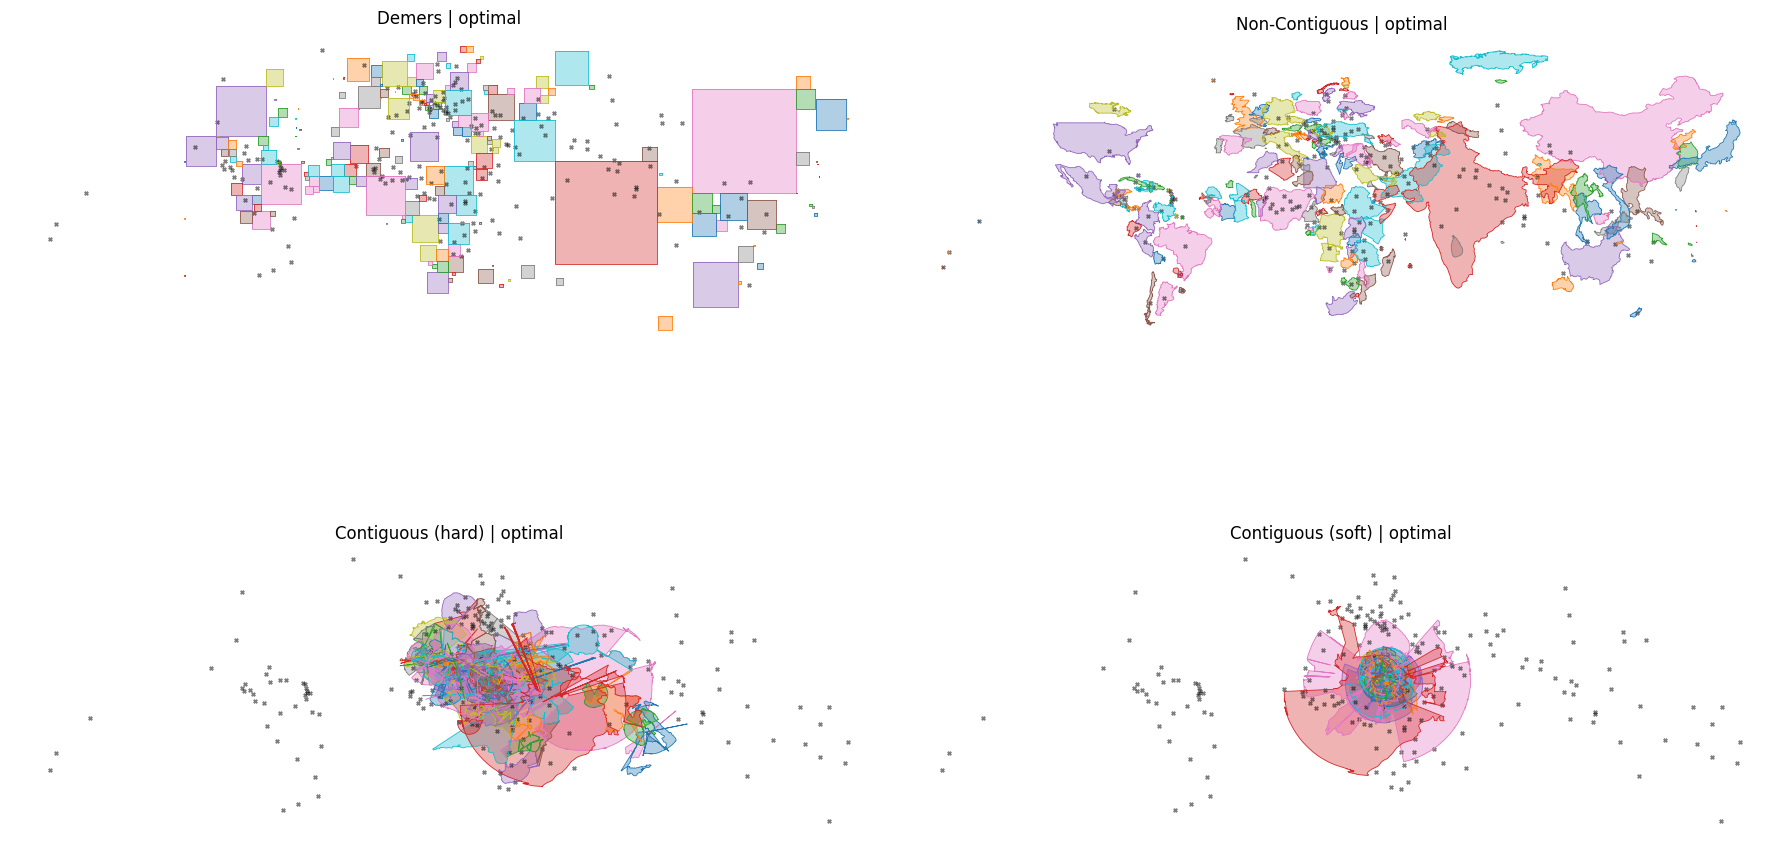

In [5]:
display(
    summary[[
        'cartogram_type',
        'status',
        'solver_ok',
        'objective',
        'mean_abs_area_err_pct',
        'median_abs_area_err_pct',
        'max_abs_area_err_pct',
        'mean_centroid_shift',
        'leaders',
        'mean_vertices',
    ]].style.format({
        'objective': '{:.4g}',
        'mean_abs_area_err_pct': '{:.3f}',
        'median_abs_area_err_pct': '{:.3f}',
        'max_abs_area_err_pct': '{:.3f}',
        'mean_centroid_shift': '{:.4f}',
        'mean_vertices': '{:.1f}',
    })
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()
for ax, (mode_name, _) in zip(axes, benchmarks):
    polygons_out, actual_areas, status, objective, leaders, target_areas_used = results[mode_name]
    draw_panel(ax, polygons_out, f'{mode_name} | {status}', target_positions, show_centers=True)

plt.tight_layout()
plt.show()

## What to inspect

- Solver status for each mode.
- Area error: large values usually mean the mode is over-constrained or the chosen weights are too aggressive.
- Mean centroid shift: this shows how far the map moved away from the reference centers.
- The plots: look for overlaps in Dorling/Demers, disconnected movement in Non-Contiguous, and whether Contiguous stays visually coherent without cleanup.

## Next experiments

- Reduce the dataset to a smaller region if the contiguous solve becomes too slow or infeasible.
- Tune `lambda_repulsion` and `lambda_vertex_distance` for Dorling if circles still overlap.
- For Contiguous, compare `shape='contiguous'` and `shape='contiguous2'` to see whether hard equality or soft coupling is more stable on your data.
- Once the raw modes are stable, add the post-processing steps back one by one and measure how much they improve area error and overlap removal.